# Bagging (Bootstrap Aggregating)

#### The Random Forest Baseline
##### Dataset: from sklearn.datasets import load_breast_cancer
##### Objective: Understand the standard implementation and advantage of bagging.
##### Task: Use scikit-learn to train a single DecisionTreeClassifier and a RandomForestClassifier on a standard dataset (like the Breast Cancer or Titanic dataset).
##### Requirements:
                _ Evaluate both models using Accuracy, Precision, Recall, and F1-score 
                _ Plot the Feature Importances extracted from the Random Forest model.
                _ Question to answer: How does the Random Forest mitigate the overfitting typically seen in deep, unpruned decision


Decision Tree
  Accuracy : 0.9474
  Precision: 0.9577
  Recall   : 0.9577
  F1-Score : 0.9577

Random Forest
  Accuracy : 0.9649
  Precision: 0.9589
  Recall   : 0.9859
  F1-Score : 0.9722


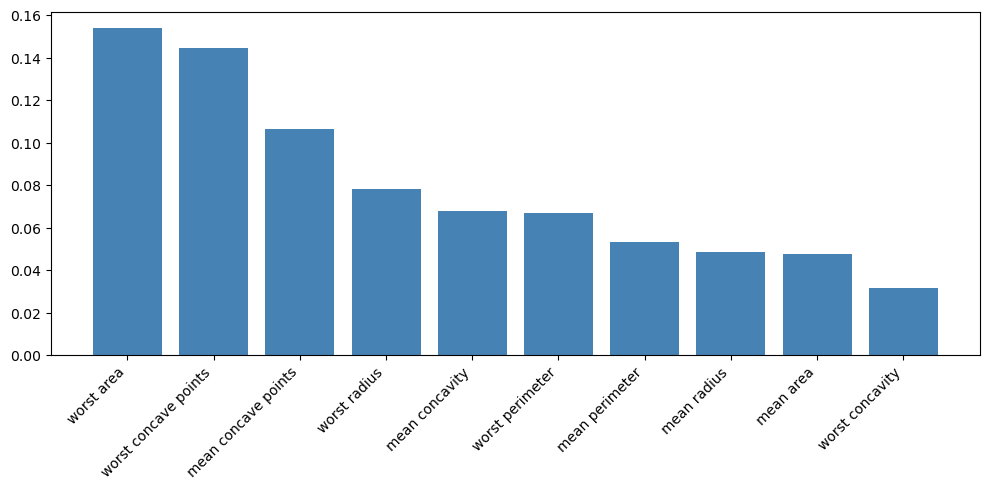

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

for name, pred in [("Decision Tree", dt_pred), ("Random Forest", rf_pred)]:
    print(f"\n{name}")
    print(f"  Accuracy : {accuracy_score(y_test, pred):.4f}")
    print(f"  Precision: {precision_score(y_test, pred):.4f}")
    print(f"  Recall   : {recall_score(y_test, pred):.4f}")
    print(f"  F1-Score : {f1_score(y_test, pred):.4f}")

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[indices], color="steelblue")
plt.xticks(range(10), data.feature_names[indices], rotation=45, ha="right")
plt.tight_layout()
plt.show()

Q: How does Random Forest mitigate overfitting?

A single decision tree grows until every leaf is pure — it memorises
the training data, so it performs worse on unseen data.

Random Forest fixes this by:
  1. Training each tree on a different random subset of the data (bagging)
  2. Considering only a random subset of features at each split

The final prediction is a majority vote across 100 trees.
Individual errors cancel out, giving a much more generalised model.

#### Building a Bagging Meta-Estimator
##### Dataset: from sklearn.datasets import load_breast_cancer
##### Objective: Understand how bootstrap sampling works under the hood.
##### Task: Instead of using RandomForestClassifier, use scikit-learn's BaggingClassifier wrapper.
##### Requirements:
               - Use a high-variance model (like a deep Decision Tree) and a low-variance model (like Logistic Regression) as the base estimators for two separate Bagging Classifiers.
               - Experiment with the max_samples and max_features hyperparameters.
               - Analyze how bagging affects the performance of the high-variance vs. low-variance base estimators differently.

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    "Decision Tree (base)":             (DecisionTreeClassifier(random_state=42), X_train, X_test),
    "Bagging + DT (default)":           (BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, random_state=42), X_train, X_test),
    "Bagging + DT (samples=0.6, feat=0.8)": (BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, max_samples=0.6, max_features=0.8, random_state=42), X_train, X_test),
    "Logistic Reg (base)":              (LogisticRegression(max_iter=10000), X_train_s, X_test_s),
    "Bagging + LR (default)":           (BaggingClassifier(LogisticRegression(max_iter=10000), n_estimators=50, random_state=42), X_train_s, X_test_s),
    "Bagging + LR (samples=0.6, feat=0.8)": (BaggingClassifier(LogisticRegression(max_iter=10000), n_estimators=50, max_samples=0.6, max_features=0.8, random_state=42), X_train_s, X_test_s),
}

print(f"\n{'Model':<42} {'Train':>7} {'Test':>7} {'Gap':>7}")
print("-" * 65)
for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    train_acc = accuracy_score(y_train, model.predict(Xtr))
    test_acc  = accuracy_score(y_test,  model.predict(Xte))
    print(f"{name:<42} {train_acc:>7.4f} {test_acc:>7.4f} {train_acc - test_acc:>7.4f}")


Model                                        Train    Test     Gap
-----------------------------------------------------------------
Decision Tree (base)                        1.0000  0.9474  0.0526
Bagging + DT (default)                      0.9978  0.9561  0.0417
Bagging + DT (samples=0.6, feat=0.8)        0.9934  0.9561  0.0373
Logistic Reg (base)                         0.9868  0.9737  0.0131
Bagging + LR (default)                      0.9868  0.9737  0.0131
Bagging + LR (samples=0.6, feat=0.8)        0.9846  0.9737  0.0109


Analysis:

Decision Tree base  → high gap (overfits, memorises training data)
Bagging + DT        → gap drops a lot (bagging helps high-variance models most)
Bagging + DT tuned  → gap drops further with max_samples / max_features

Logistic Reg base   → tiny gap already (low-variance model, doesn't overfit)
Bagging + LR        → almost no change (nothing to fix)
Bagging + LR tuned  → still barely changes

Conclusion: bagging is a variance-reduction tool.
It helps high-variance models (DT) a lot, low-variance models (LR) almost nothing.